In [14]:
import xarray as xr
import glob
import matplotlib.pyplot as plt

In [15]:
import dask
import dask.array as da
from dask_jobqueue import PBSCluster
from dask.distributed import Client, wait
dask.config.set(**{'array.slicing.split_large_chunks': False}) #supress warning about large chunk

# Setup your PBSCluster
cluster = PBSCluster(
                    cores=1,
                    memory='70GB', # Amount of memory
                    processes=1,
                    queue='casper',
                    local_directory='$TMPDIR', # Use your local directory
                    resource_spec='select=1:ncpus=1:mem=70GB',
                    walltime='8:00:00',
                    interface='ext',
                    )

# Scale up
cluster.scale(15)
client = Client(cluster)
client.wait_for_workers(10)  # waits until >=10 workers are connected
client

<Client: 'tcp://128.117.208.158:36907' processes=7 threads=7, memory=456.33 GiB>

In [17]:
base_path = '/glade/campaign/cisl/aiml/wchapman/MLWPS/STAGING/'
train_data_fi = base_path+'b.e21.CREDIT_climate_branch_1980_????_zmdata_ERA5scaled_zmdata_Qtot.zarr'
mean_data_fi = base_path+'mean_6h_1980_Coupled_2000_2012_32lev_1.0deg_ERA5scaled_F32_Qtot_Mixed_Modal.nc'
std_data_fi = base_path+'std_6h_1980_Coupled_2000_2012_32lev_1.0deg_ERA5scaled_F32_Qtot_Mixed_Modal.nc'

In [18]:
train_files = sorted(glob.glob(train_data_fi))

In [19]:
train_data = xr.open_mfdataset(train_files, engine='zarr')
mean = xr.open_dataset(mean_data_fi)
std = xr.open_dataset(std_data_fi)

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr

In [62]:
train_standardized = (train_data - mean)/std
climo_doy_00 = train_standardized.where(train_standardized.time.dt.hour==0, drop=True).groupby("time.dayofyear").mean("time")
print('...1...')
climo_doy_06 = train_standardized.where(train_standardized.time.dt.hour==6, drop=True).groupby('time.dayofyear').mean('time')
print('...2...')
climo_doy_12 = train_standardized.where(train_standardized.time.dt.hour==12, drop=True).groupby('time.dayofyear').mean('time')
print('...3...')
climo_doy_18 = train_standardized.where(train_standardized.time.dt.hour==18, drop=True).groupby('time.dayofyear').mean('time')
print('...4...')

# ...centered rolling window that wraps around the year. 
climCyclical = xr.concat([climo_doy_00, climo_doy_00, climo_doy_00], dim="dayofyear")
climSmooth0 = climCyclical.rolling(dayofyear=15, center=True).mean()
climSmooth0 = climSmooth0.rolling(dayofyear=15, center=True).mean()
climSmooth_00 = climSmooth0.isel(dayofyear=slice(365, 365+365))

climCyclical = xr.concat([climo_doy_06, climo_doy_06, climo_doy_06], dim="dayofyear")
climSmooth0 = climCyclical.rolling(dayofyear=15, center=True).mean()
climSmooth0 = climSmooth0.rolling(dayofyear=15, center=True).mean()
climSmooth_06 = climSmooth0.isel(dayofyear=slice(365, 365+365))

climCyclical = xr.concat([climo_doy_12, climo_doy_12, climo_doy_12], dim="dayofyear")
climSmooth0 = climCyclical.rolling(dayofyear=15, center=True).mean()
climSmooth0 = climSmooth0.rolling(dayofyear=15, center=True).mean()
climSmooth_12 = climSmooth0.isel(dayofyear=slice(365, 365+365))

climCyclical = xr.concat([climo_doy_18, climo_doy_18, climo_doy_18], dim="dayofyear")
climSmooth0 = climCyclical.rolling(dayofyear=15, center=True).mean()
climSmooth0 = climSmooth0.rolling(dayofyear=15, center=True).mean()
climSmooth_18 = climSmooth0.isel(dayofyear=slice(365, 365+365))

climo_doy = xr.concat([climSmooth_00 , climSmooth_06, climSmooth_12, climSmooth_18], dim='hour').assign_coords(hour = [0,6,12,18])
climo_doy

...1......1......1......1......1...
...2...
...3...
...4...


## Save Out 

In [78]:
# 1. Strip ALL encoding from every variable to avoid the TypeError
for var in climo_doy.variables:
    climo_doy[var].encoding = {}

# 2. Re-apply chunking. Since we stripped encoding, we do it here.
# Use a uniform size for the 2nd dimension (e.g., 15) to fix the "final chunk" error.
# I'll use the generic index-based dimension name, but replace 'doy' with yours.
dim_names = list(climo_doy['SNOWQM'].dims)
target_dim = dim_names[1]  # This is the one with the (14, ..., 15) issue

climo_doy = climo_doy.chunk({target_dim: 15})

# 3. Save to Zarr
save_path = '/glade/derecho/scratch/wchapman/CUVACAR/'
file_name = 'b.e21.CREDIT_climate_branch_1980-2014climo_zmdata_ERA5scaled_zmdata_Qtot_v3.zarr'

climo_doy.to_zarr(save_path + file_name, mode='w')

ValueError: Final chunk of Zarr array must be the same size or smaller than the first. Variable named 'SNOWQM' has incompatible Dask chunks ((1, 1, 1, 1), (14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15), (32,), (192,), (288,)).Consider either rechunking using `chunk()` or instead deleting or modifying `encoding['chunks']`.

In [80]:
# 1. Strip ALL encoding from every variable to avoid the TypeError
for var in climo_doy.variables:
    climo_doy[var].encoding = {}

# 2. Re-apply chunking. Since we stripped encoding, we do it here.
# Use a uniform size for the 2nd dimension (e.g., 15) to fix the "final chunk" error.
# I'll use the generic index-based dimension name, but replace 'doy' with yours.
dim_names = list(climo_doy['SNOWQM'].dims)
target_dim = dim_names[1]  # This is the one with the (14, ..., 15) issue

climo_doy = climo_doy.chunk({target_dim: 15})

# 3. Save to Zarr
save_path = '/glade/derecho/scratch/wchapman/CUVACAR/'
file_name = 'b.e21.CREDIT_climate_branch_1980-2014climo_zmdata_ERA5scaled_zmdata_Qtot_v3.zarr'

climo_doy.to_zarr(save_path + file_name, mode='w')


/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 579.20 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [12]:
import xarray as xr
import pandas as pd

DS = xr.open_zarr('/glade/derecho/scratch/wchapman/CUVACAR/b.e21.CREDIT_climate_branch_1980-2014climo_zmdata_ERA5scaled_zmdata_Qtot_v3.zarr/')

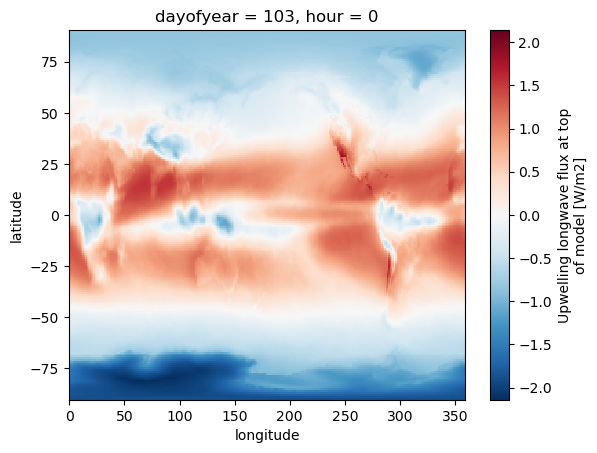

In [6]:
DS['FLUT'].isel(hour=0,dayofyear=102).plot()

In [17]:
TIME_Init = pd.date_range(start='1981-01-01', end = '1981-12-31', freq='6H')

/glade/derecho/scratch/wchapman/tmp/ipykernel_124373/4111981484.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  TIME_Init = pd.date_range(start='1981-01-01', end = '1981-12-31', freq='6H')


In [7]:
DS

<xarray.Dataset> Size: 187GB
Dimensions:    (hour: 4, dayofyear: 365, latitude: 192, longitude: 288,
                level: 32, ilev: 33)
Coordinates:
  * hour       (hour) int64 32B 0 6 12 18
  * dayofyear  (dayofyear) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * latitude   (latitude) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * longitude  (longitude) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
  * level      (level) float64 256B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev       (ilev) float64 264B 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
Data variables: (12/43)
    CLDHGH     (hour, dayofyear, latitude, longitude) float64 646MB dask.array<chunksize=(1, 15, 192, 288), meta=np.ndarray>
    CLDLOW     (hour, dayofyear, latitude, longitude) float64 646MB dask.array<chunksize=(1, 15, 192, 288), meta=np.ndarray>
    CLDMED     (hour, dayofyear, latitude, longitude) float64 646MB dask.array<chunksize=(1, 15, 192, 288), meta=np.ndarray>
    CLDTOT     (hour, dayofyear, latitude, longitude) float64 646MB dask.array<chunksize=(1, 15, 192, 288), meta=np.ndarray>
    co2vmr     (hour, dayofyear) float64 12kB dask.array<chunksize=(1, 15), meta=np.ndarray>
    co2vmr_3d  (hour, dayofyear, latitude, longitude) float64 646MB dask.array<chunksize=(1, 15, 192, 288), meta=np.ndarray>
    ...         ...
    TS         (hour, dayofyear, latitude, longitude) float64 646MB dask.array<chunksize=(1, 15, 192, 288), meta=np.ndarray>
    U          (hour, dayofyear, level, latitude, longitude) float64 21GB dask.array<chunksize=(1, 15, 32, 192, 288), meta=np.ndarray>
    U10        (hour, dayofyear, latitude, longitude) float64 646MB dask.array<chunksize=(1, 15, 192, 288), meta=np.ndarray>
    V          (hour, dayofyear, level, latitude, longitude) float64 21GB dask.array<chunksize=(1, 15, 32, 192, 288), meta=np.ndarray>
    Z500       (hour, dayofyear, latitude, longitude) float64 646MB dask.array<chunksize=(1, 15, 192, 288), meta=np.ndarray>
    ZMMU       (hour, dayofyear, level, latitude, longitude) float64 21GB dask.array<chunksize=(1, 15, 32, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.CREDIT_climate_branch_1980
    logname:           wchapman
    host:              derecho3
    initial_file:      b.e21.BHIST.f09_g17.CMIP6-historical.001.cam.i.1980-01...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/f...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  hour_6

In [11]:
import pandas as pd